## Explorative Datenanalyse
In der explorativen Datenanalyse wird der bereinigte Datensatz deskriptiv untersucht. Ziel ist es, die Verteilung der Zielvariable Hypertonie sowie wichtige Zusammenhänge mit potenziellen Risikofaktoren wie Alter, Geschlecht, BMI und Taillenumfang zu beschreiben.

Zunächst wird geprüft, wie viele Personen und Variablen nach dem Data Cleaning im Datensatz enthalten sind.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [14]:
df = pd.read_csv('nhanes_cleand.csv')

In [15]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6266 entries, 0 to 6265
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   pat_id                   6266 non-null   float64
 1   hypertension             6266 non-null   float64
 2   gender                   6266 non-null   str    
 3   age                      6266 non-null   float64
 4   weight(kg)               6266 non-null   float64
 5   height(cm)               6266 non-null   float64
 6   bmi                      6266 non-null   float64
 7   waist_circumference(cm)  6266 non-null   float64
 8   age_category             6266 non-null   str    
 9   bmi_category             6266 non-null   str    
dtypes: float64(7), str(3)
memory usage: 489.7 KB


In [16]:
# zwischen 6.266 Teilnehmer Wie viele Personen haben Hypertonie und wie viele nicht?
df["hypertension"].value_counts(normalize=True) * 100

hypertension
0.0    65.209065
1.0    34.790935
Name: proportion, dtype: float64

Die Verteilung wurde geprüft, um die Struktur der numerischen Variablen besser zu verstehen und mögliche auffällige Werte zu erkennen. Besonders Alter, BMI und Taillenumfang sind für die Fragestellung relevant, da sie potenzielle Risikofaktoren für Hypertonie darstellen.

Die Zielvariable wird untersucht, um zu sehen, ob die Klassen ungefähr ausgeglichen sind oder ob ein Ungleichgewicht zwischen Personen mit und ohne Hypertonie besteht.

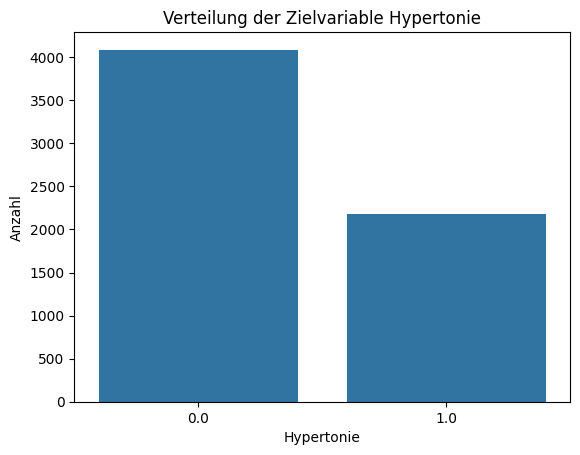

In [17]:
# die Verteilung der Zielvariable 

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="hypertension")
plt.title("Verteilung der Zielvariable Hypertonie")
plt.xlabel("Hypertonie")
plt.ylabel("Anzahl")
plt.show()

### 1. Deskriptive Statistik der numerischen Variablen:

Wie sind `Alter`, `BMI ` und `Taillenumfang` verteilt?

In [18]:
df[["age", "bmi", "waist_circumference(cm)"]].describe()

,age,bmi,waist_circumference(cm)
count,6266.000000,6266.000000,6266.000000
mean,50.604054,29.355346,99.750207
std,19.206081,7.230703,17.396638
min,16.000000,11.100000,59.600000
25%,34.000000,24.300000,87.125000
50%,54.000000,28.100000,98.400000
75%,67.000000,33.100000,110.500000
max,80.000000,69.900000,187.000000


Die deskriptive Statistik zeigt, dass der finale Datensatz 6266 Personen umfasst. Das Alter liegt zwischen 16 und 80 Jahren, mit einem Median von 54 Jahren. Der BMI weist einen Mittelwert von 29,4 und einen Median von 28,1 auf, was auf eine insgesamt erhöhte BMI-Verteilung hindeutet. Der Taillenumfang liegt im Median bei 98,4 cm. Bei BMI und Taillenumfang sind einzelne sehr hohe Werte erkennbar, die im weiteren Verlauf als mögliche extreme Werte berücksichtigt werden sollten.

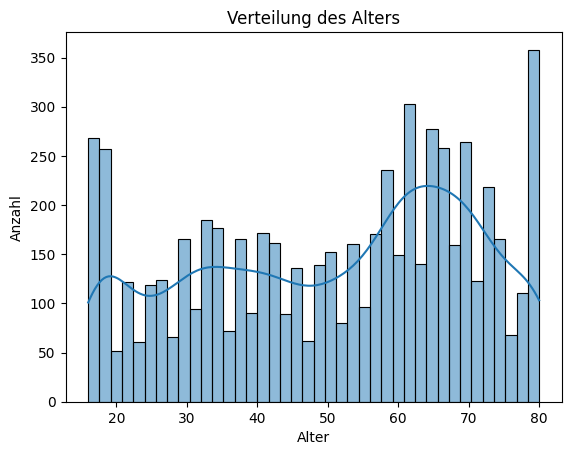

In [19]:
sns.histplot(data=df, x="age", bins=40, kde=True)
plt.title("Verteilung des Alters")
plt.xlabel("Alter")
plt.ylabel("Anzahl")
plt.show()

Die Altersverteilung zeigt, dass Personen aus einem breiten Altersbereich im Datensatz enthalten sind. Besonders die Altersgruppe zwischen etwa 50 und 70 Jahren ist stark vertreten. Da Hypertonie mit zunehmendem Alter häufiger auftritt, ist die Altersstruktur des Datensatzes für die spätere Analyse und Modellierung besonders relevant. Die ungleichmäßige Verteilung sollte bei der Interpretation der Ergebnisse berücksichtigt werden.

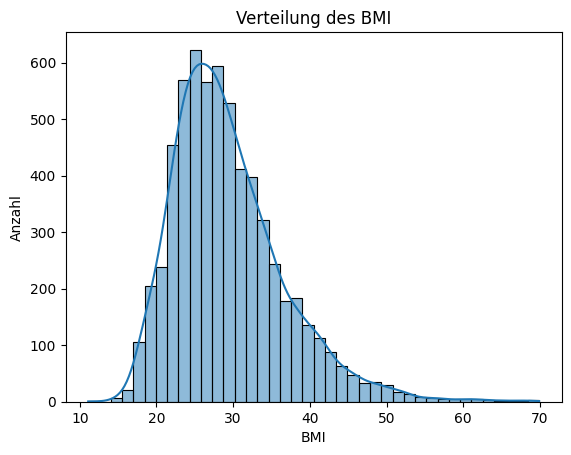

In [20]:
sns.histplot(data=df, x="bmi", bins=40, kde=True)
plt.title("Verteilung des BMI")
plt.xlabel("BMI")
plt.ylabel("Anzahl")
plt.show()

Die BMI-Verteilung ist rechtsschief. Die meisten Personen liegen im Bereich zwischen etwa 24 und 33. Einzelne sehr hohe BMI-Werte bis etwa 70 sind erkennbar und sollten als potenzielle Ausreißer bzw. extreme Werte geprüft werden. Da ein erhöhter BMI ein potenzieller Risikofaktor für Hypertonie ist, ist diese Variable für die weitere Analyse und Modellierung relevant.

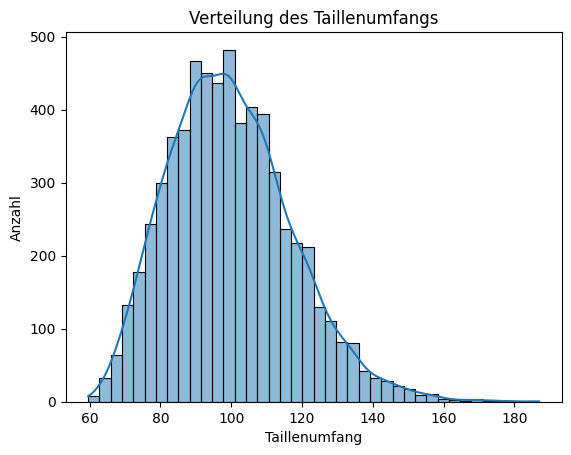

In [21]:
sns.histplot(data=df, x="waist_circumference(cm)", bins=40, kde=True)
plt.title("Verteilung des Taillenumfangs")
plt.xlabel("Taillenumfang")
plt.ylabel("Anzahl")
plt.show()

Die Verteilung des Taillenumfangs zeigt eine Häufung der Werte im Bereich von etwa 80 bis 120 cm. Der Median liegt bei 98,4 cm und der Mittelwert bei 99,8 cm. Die Verteilung ist leicht rechtsschief, da einzelne hohe Werte bis 187 cm vorkommen. Da ein erhöhter Taillenumfang ein potenzieller Risikofaktor für Hypertonie ist, ist diese Variable für die weitere Analyse und Modellierung relevant.

## Hypertonie nach Geschlecht

Unterscheidet sich Hypertonie zwischen Männern und Frauen?

In [48]:
pd.crosstab(df["gender"], df["hypertension"])

hypertension,0.0,1.0
gender,,
Female,2258,1153
Male,1828,1027


In [49]:
gender_hyp = pd.crosstab(
    df["gender"],
    df["hypertension"],
    normalize="index"
) * 100

gender_hyp.round(2)

hypertension,0.0,1.0
gender,,
Female,66.20,33.80
Male,64.03,35.97


Die prozentuale Auswertung zeigt, dass der Anteil der Personen mit Hypertonie bei Männern mit 36,0 % etwas höher ist als bei Frauen mit 33,8 %. In beiden Gruppen überwiegt jedoch der Anteil der Personen ohne Hypertonie. Der Unterschied zwischen den Geschlechtern ist eher gering und sollte daher vorsichtig interpretiert werden.

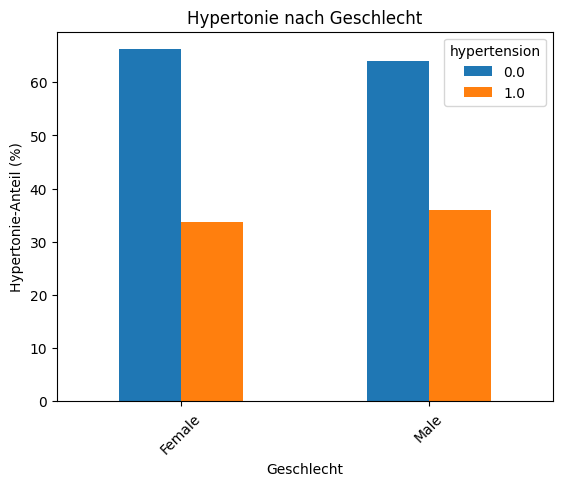

In [52]:
gender_hyp.plot(kind="bar")

plt.title('Hypertonie nach Geschlecht')
plt.xlabel('Geschlecht')
plt.ylabel('Hypertonie-Anteil (%)')
plt.xticks(rotation=45)
plt.show()

Der Plot zeigt die Verteilung von Hypertonie nach Geschlecht. In beiden Geschlechtsgruppen ist die Anzahl der Personen ohne Hypertonie höher als die Anzahl der Personen mit Hypertonie. 

**Fazit**:
Geschlecht kann als Feature aufgenommen werden, aber der beobachtete Unterschied ist relativ gering. Wahrscheinlich werden Variablen wie Alter, BMI und Taillenumfang für die Vorhersage stärker relevant sein.

## Hypertonie nach Altersgruppen

Steigt der Anteil von Hypertonie mit dem Alter?

In [58]:
age_hyp = pd.crosstab(
    df["age_category"],
    df["hypertension"],
    normalize="index"
) * 100


age_hyp.round(2)

hypertension,0.0,1.0
age_category,,
20-29,93.45,6.55
30-39,86.04,13.96
40-49,75.23,24.77
50-59,56.65,43.35
60+,45.14,54.86
<20,96.38,3.62


In [59]:
age_order = ["<20", "20-29", "30-39", "40-49", "50-59", "60+"]
age_hyp = (
    df.groupby("age_category")["hypertension"]
    .mean()
    .reindex(age_order)
    * 100
)

age_hyp.round(2)

age_category
<20       3.62
20-29     6.55
30-39    13.96
40-49    24.77
50-59    43.35
60+      54.86
Name: hypertension, dtype: float64

Die Auswertung nach Altersgruppen zeigt einen deutlichen **Anstieg** des Hypertonie-Anteils mit **zunehmendem Alter**. Während in der Altersgruppe 20–29 nur 6,55 % eine Hypertonie aufweisen, liegt der Anteil in der Gruppe 60+ bei 54,86 %. Besonders ab der Altersgruppe 40–49 steigt der Anteil deutlich an. Dies spricht dafür, dass Alter ein wichtiger Prädiktor für Hypertonie ist und in der späteren Modellierung berücksichtigt werden sollte.

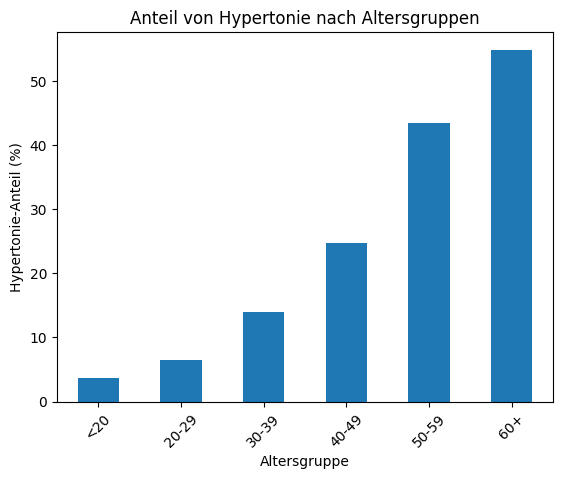

In [37]:
age_hyp.plot(kind="bar")

plt.title("Anteil von Hypertonie nach Altersgruppen")
plt.xlabel("Altersgruppe")
plt.ylabel("Hypertonie-Anteil (%)")
plt.xticks(rotation=45)
plt.show()

## Hypertonie nach BMI

Unterscheidet sich die BMI-Kategorien zwischen Personen mit Hypertonie?

In [38]:
bmi_order = ["underweight", "normal_weight", "overweight", "obesity"]
bmi_hyp = (
    df.groupby("bmi_category")["hypertension"]
    .mean()
    .reindex(bmi_order)
    * 100
)

bmi_hyp.round(2)

bmi_category
underweight       8.51
normal_weight    21.60
overweight       33.96
obesity          46.13
Name: hypertension, dtype: float64

In [27]:
df.groupby("hypertension")["bmi"].describe()

,count,mean,std,min,25%,50%,75%,max
hypertension,,,,,,,,
0.0,4086.0,28.163338,6.822980,11.1,23.4,26.9,31.6,69.9
1.0,2180.0,31.589541,7.442504,15.2,26.3,30.2,35.4,68.9


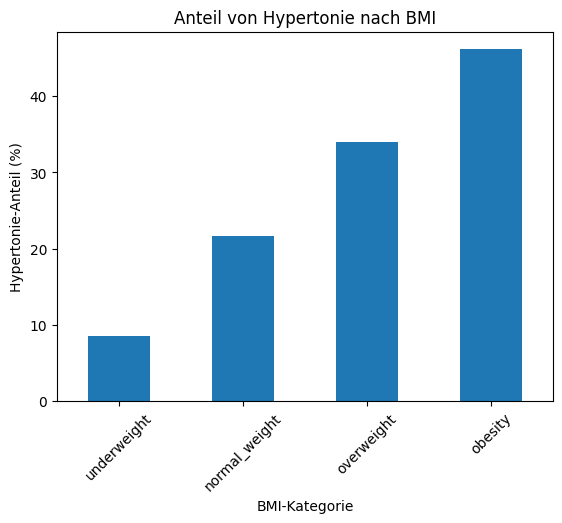

In [65]:
bmi_hyp.plot(kind="bar")

plt.title("Anteil von Hypertonie nach BMI")
plt.xlabel("BMI-Kategorie")
plt.ylabel("Hypertonie-Anteil (%)")
plt.xticks(rotation= 45)
plt.show()

Die Auswertung nach BMI-Kategorien zeigt, ob der Hypertonie-Anteil mit zunehmender BMI-Kategorie steigt. Wenn Personen mit Übergewicht oder Adipositas einen höheren Hypertonie-Anteil aufweisen als Personen mit Normalgewicht, spricht dies für einen Zusammenhang zwischen erhöhtem BMI und Hypertonie. Für die Modellierung kann BMI daher als relevantes numerisches Feature berücksichtigt werden.

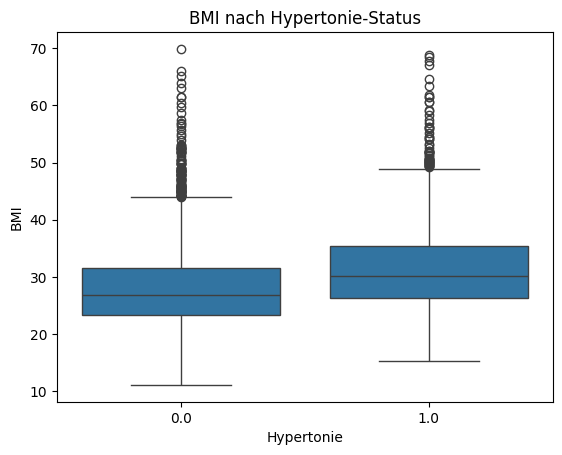

In [60]:
sns.boxplot(data=df, x="hypertension", y="bmi")

plt.title("BMI nach Hypertonie-Status")
plt.xlabel("Hypertonie")
plt.ylabel("BMI")
plt.show()

Der BMI wurde zwischen Personen mit und ohne Hypertonie verglichen. Der Boxplot zeigt, ob sich Median, Streuung und mögliche Ausreißer zwischen den beiden Gruppen unterscheiden. Der Median und die Box der Hypertonie-Gruppe höher liegen, deutet dies darauf hin, dass Personen mit Hypertonie tendenziell höhere BMI-Werte aufweisen. Ein höherer BMI kann daher als potenziell relevantes Feature für die Modellierung betrachtet werden.

## Hypertonie nach Taillenumfang
Unterscheidet sich der Taillenumfang zwischen Personen mit Hypertonie?

In [29]:
df.groupby("hypertension")["waist_circumference(cm)"].describe()

,count,mean,std,min,25%,50%,75%,max
hypertension,,,,,,,,
0.0,4086.0,95.935340,16.486424,59.6,83.900,94.2,106.000,177.7
1.0,2180.0,106.900459,16.797627,64.2,95.175,106.0,117.125,187.0


Bei Personen ohne Hypertonie liegt der Median des Taillenumfangs ungefähr bei 94 cm. Bei Personen mit Hypertonie liegt der Median ungefähr bei 106 cm.

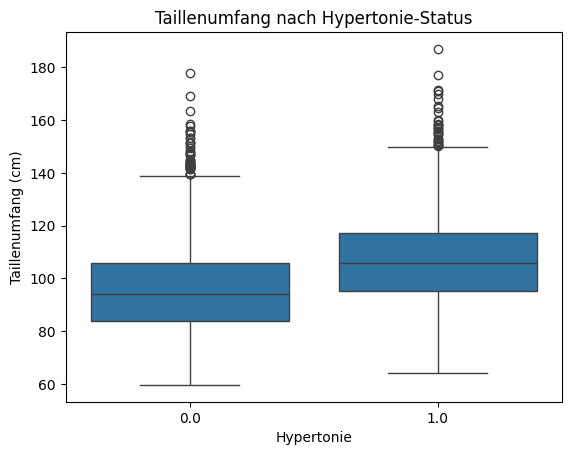

In [30]:
sns.boxplot(data=df, x="hypertension", y="waist_circumference(cm)")
plt.title("Taillenumfang nach Hypertonie-Status")
plt.xlabel("Hypertonie")
plt.ylabel("Taillenumfang (cm)")
plt.show()

Der Boxplot zeigt, dass Personen mit Hypertonie im Median einen höheren Taillenumfang aufweisen als Personen ohne Hypertonie. Auch der mittlere Wertebereich liegt bei der Hypertonie-Gruppe insgesamt höher. Dies deutet darauf hin, dass ein höherer Taillenumfang mit Hypertonie assoziiert sein kann. In beiden Gruppen sind einzelne hohe Werte erkennbar, die als mögliche extreme Werte berücksichtigt werden sollten.

### Korrelationsanalyse numerischer Variablen

Wie hängen numerische Variablen miteinander zusammen?

Die Spearman-Korrelation wird verwendet, um monotone Zusammenhänge zwischen numerischen Variablen zu untersuchen.

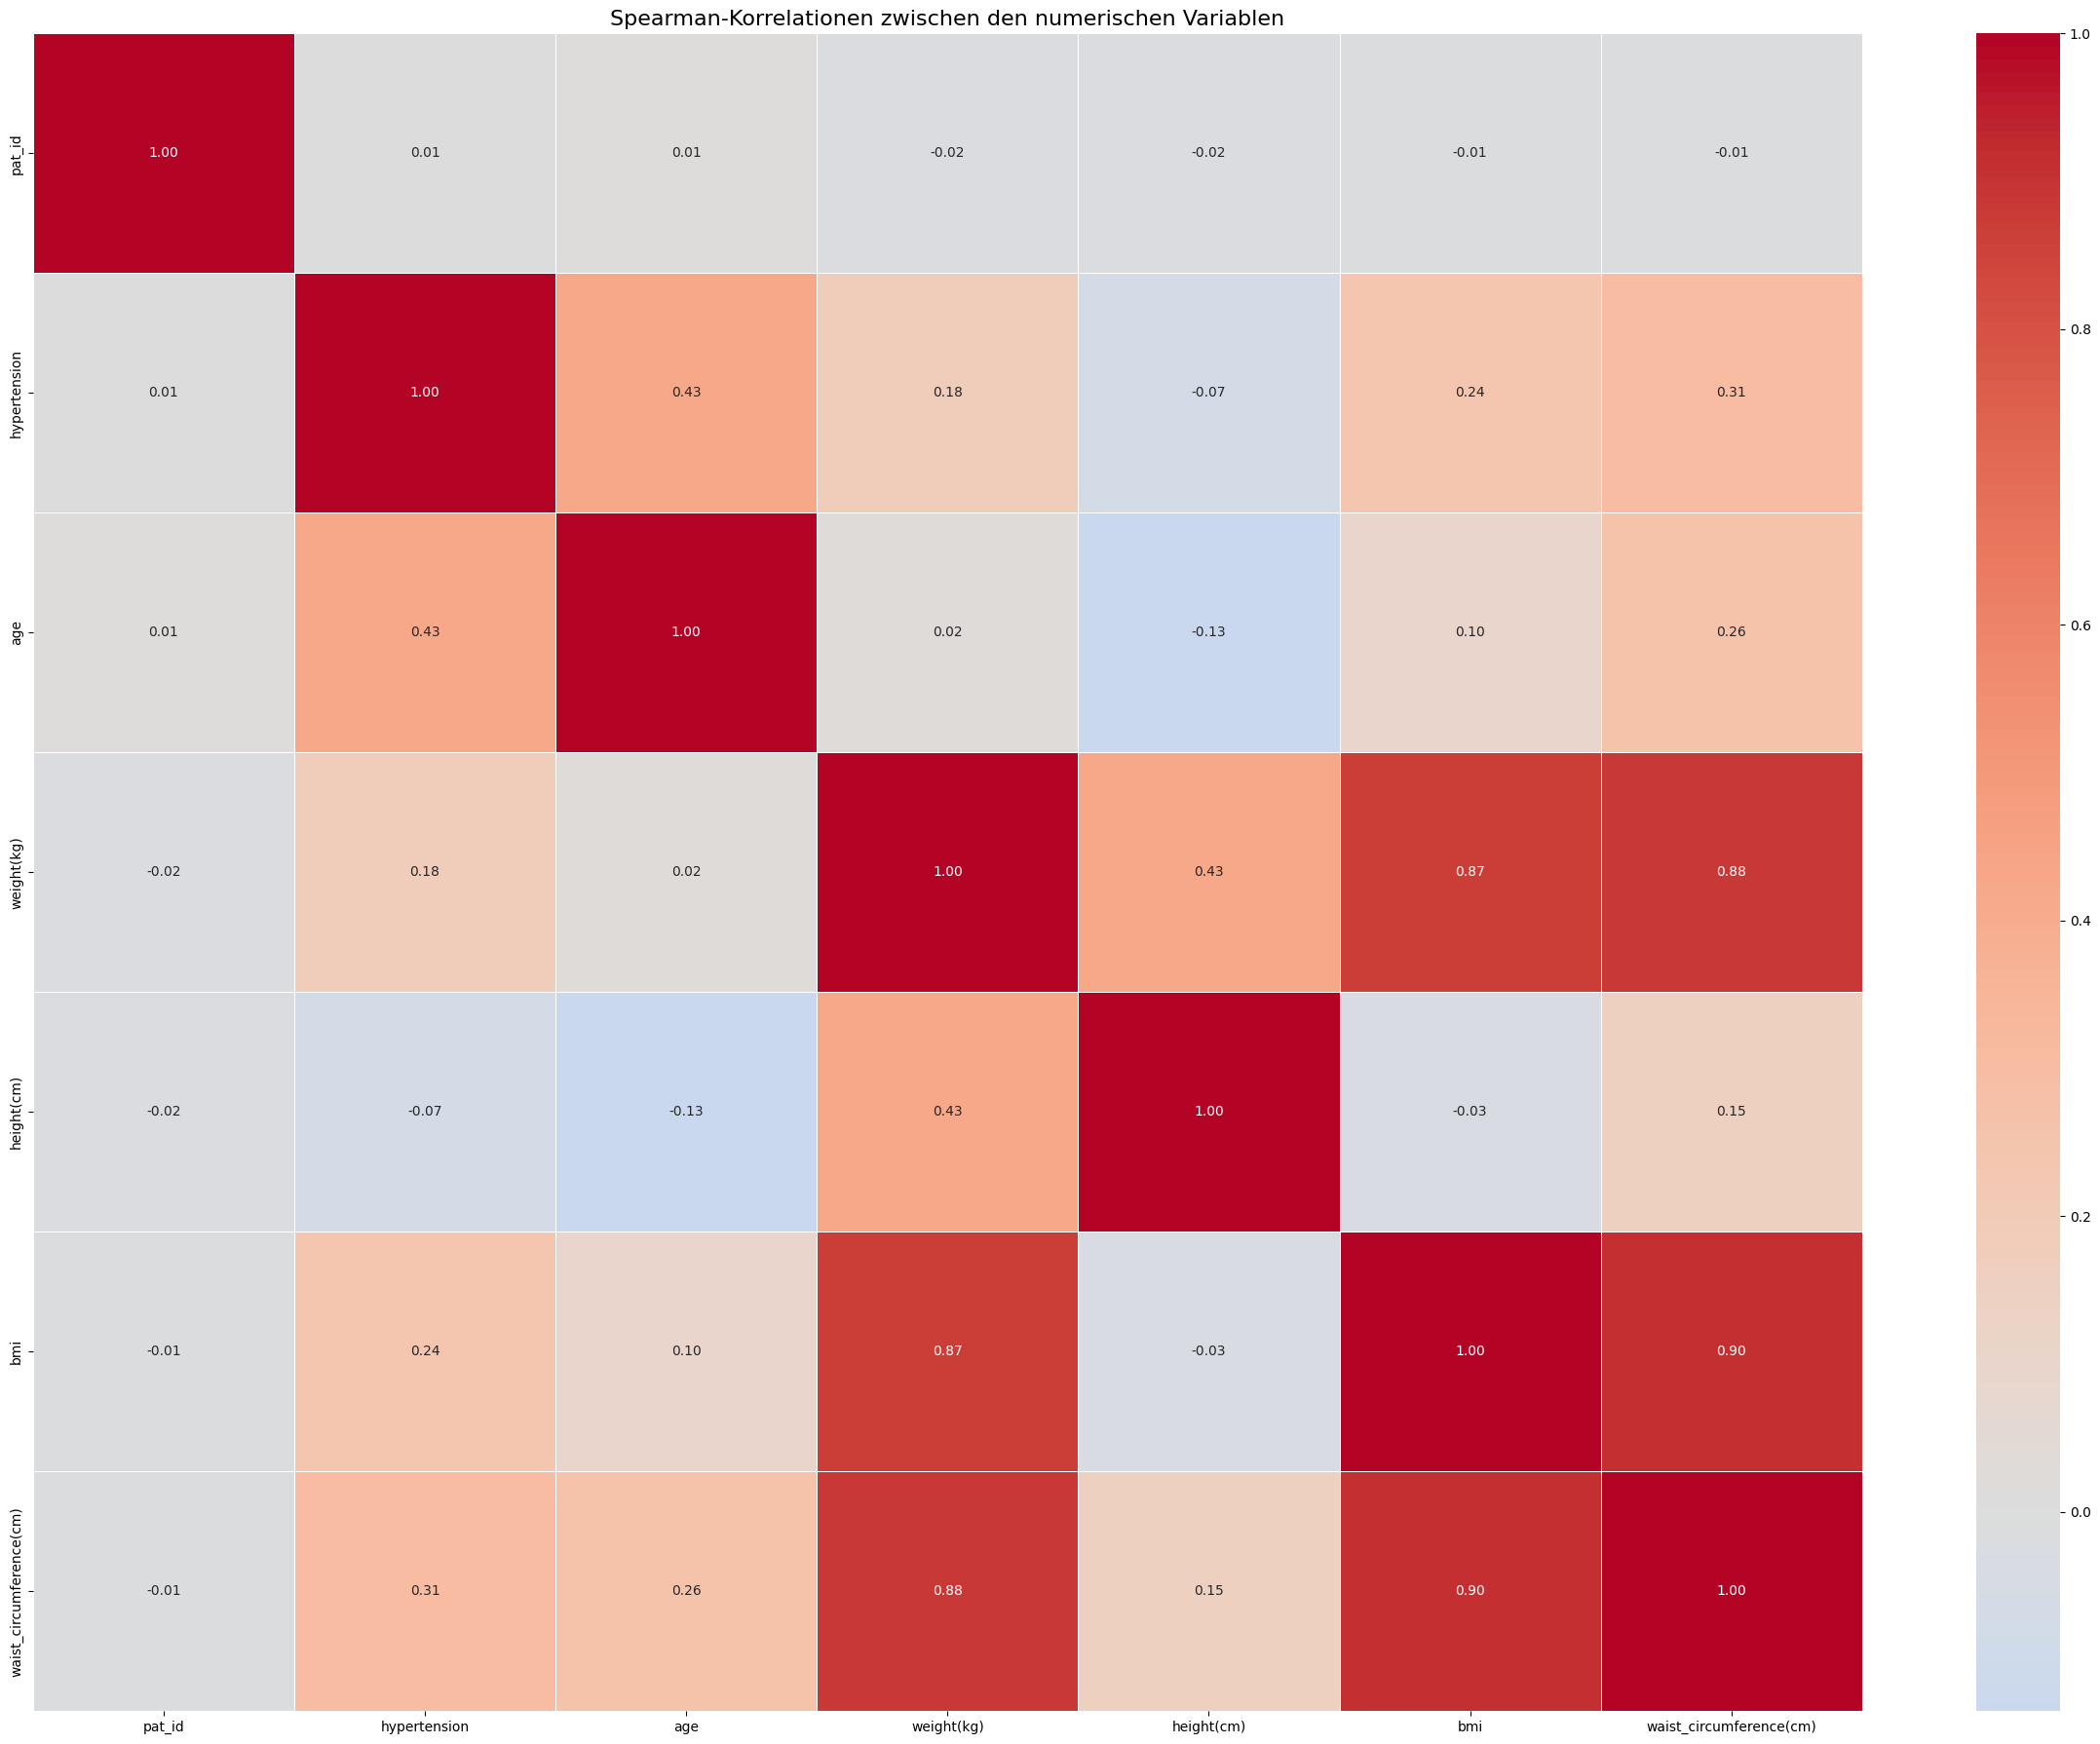

In [31]:
# Kopie des Datensatzes für die Korrelationsanalyse erstellen
df_graph = df.copy()

# Spearman-Korrelationsmatrix für numerische Variablen berechnen
corr_matrix = df_graph.corr(
    numeric_only=True,
    method="spearman"
)

# Heatmap der Korrelationsmatrix erstellen
plt.figure(figsize=(24, 18))

sns.heatmap(
    corr_matrix,
    annot=True,        
    fmt=".2f",         
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Spearman-Korrelationen zwischen den numerischen Variablen", fontsize=16)
plt.tight_layout()
plt.show()

In [32]:
corr_matrix.round(2)

#Spearman-r	Stärke
#0.00 bis 0.19	sehr schwach
#0.20 bis 0.39	schwach
##0.40 bis 0.59	moderat
#0.60 bis 0.79	stark
#0.80 bis 1.00	sehr stark

,pat_id,hypertension,age,weight(kg),height(cm),bmi,waist_circumference(cm)
pat_id,1.00,0.01,0.01,-0.02,-0.02,-0.01,-0.01
hypertension,0.01,1.00,0.43,0.18,-0.07,0.24,0.31
age,0.01,0.43,1.00,0.02,-0.13,0.10,0.26
weight(kg),-0.02,0.18,0.02,1.00,0.43,0.87,0.88
height(cm),-0.02,-0.07,-0.13,0.43,1.00,-0.03,0.15
bmi,-0.01,0.24,0.10,0.87,-0.03,1.00,0.90
waist_circumference(cm),-0.01,0.31,0.26,0.88,0.15,0.90,1.00


### Kurze Zusammenfassung der EDA-Ergebnisse

Die explorative Datenanalyse zeigte, wie häufig Hypertonie im finalen Datensatz vorkommt und wie sich zentrale Risikofaktoren verteilen. Besonders Alter, BMI und Taillenumfang wurden im Zusammenhang mit Hypertonie betrachtet. Zusätzlich wurden Gruppenunterschiede nach Geschlecht, Altersgruppen und BMI-Kategorien untersucht. Die Ergebnisse der EDA dienen als Grundlage für die Auswahl und Interpretation der Variablen im anschließenden Machine-Learning-Modell.